# Laboratorio 4 – Árboles de Decisión

In [95]:
import pyreadr                          # Lectura de archivos .Rdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento 
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos 
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text, plot_tree
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans

# Métricas 
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Estilo gráfico
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

## 1. Carga de Datos

In [96]:
# 1.1 Lectura del archivo 
result = pyreadr.read_r('listings.Rdata')   # Cambiar ruta si es necesario
# Convierte el objeto R en un diccionario de DataFrames de Pandas sin necesidad de tener R instalado.
# El archivo puede contener uno o varios objetos R; tomamos el primero
df_raw = result[list(result.keys())[0]].copy()

print(f"Objeto(s) en el archivo: {list(result.keys())}")
print(f"\nDimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")


Objeto(s) en el archivo: ['listings']

Dimensiones: 171,748 filas x 80 columnas


In [97]:
# 1.2 Estructura del dataset
print("\nTIPOS DE DATOS ")
print(df_raw.dtypes.head(80))

print("\nPRIMERAS 5 FILAS")
df_raw.head()



TIPOS DE DATOS 
id                                              float64
listing_url                                      object
scrape_id                                       float64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count_entire_homes       int32
calculated_host_listings_count_private_rooms      int32
calculated_host_listings_count_shared_rooms       int32
reviews_per_month                               float64
city                                             object
Length: 80, dtype: object

PRIMERAS 5 FILAS


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [98]:
# 1.3 Estadísticas descriptivas
df_raw.describe(include='number').T.style.background_gradient(cmap='Blues', axis=1)


,count,mean,std,min,25%,50%,75%,max
id,171748.000000,636291457352466304.000000,583492767102072064.000000,6.000000,35992997.750000,724955743120853504.000000,1182638277348256000.000000,1567804186654919936.000000
scrape_id,171748.000000,20251067780923.519531,141962486.493073,20250916040722.000000,20250916040734.000000,20251204025409.000000,20251204025459.000000,20251204025459.000000
host_id,171748.000000,200257103.404290,204882973.685601,23.000000,26330631.000000,108058504.500000,376574507.000000,732092326.000000
latitude,171748.000000,33.776320,7.236441,18.989648,30.381088,34.089840,40.702460,42.391844
longitude,171748.000000,-109.489530,30.024424,-159.716528,-118.591115,-117.865347,-73.997148,-70.996000
accommodates,171748.000000,4.106796,2.836661,1.000000,2.000000,4.000000,6.000000,16.000000
bathrooms,140352.000000,1.551795,1.014407,0.000000,1.000000,1.000000,2.000000,32.500000
minimum_nights,171748.000000,16.996559,30.014597,1.000000,2.000000,4.000000,30.000000,1125.000000
maximum_nights,171748.000000,12988.269540,5181839.672298,1.000000,90.000000,365.000000,1125.000000,2147483647.000000
minimum_nights_avg_ntm,171748.000000,17.487677,30.788964,0.700000,2.000000,4.400000,30.000000,1125.000000


### Interpretación de tipos de variables

| Tipo | Variables clave | Rol en el modelo |
|---|---|---|
| **Numéricas continuas** | `price`, `review_scores_rating`, `latitude`, `longitude` | Predictores y target |
| **Numéricas discretas** | `accommodates`, `bedrooms`, `beds`, `bathrooms` | Predictores clave |
| **Categóricas nominales** | `room_type`, `property_type`, `neighbourhood_cleansed` | Requieren encoding |
| **Booleanas** | `host_is_superhost`, `instant_bookable` | Binarias (0/1) |
| **Fechas** | `host_since`, `first_review`, `last_review` | Se extraerá antigüedad |
| **Texto libre / URLs** | `name`, `description`, `listing_url`, `picture_url` | Se eliminarán |


## 2. Análisis Exploratorio de Datos

### 2.1 Limpieza inicial del precio

In [99]:
# Airbnb almacena el precio como string con símbolo de moneda: "$1,200.00"
# Debemos quitar el "$" y las comas, luego convertir a float.

df = df_raw.copy()

if df['price'].dtype == object:
    df['price'] = (df['price']
                   .str.replace(r'[\$,]', '', regex=True)
                   .str.strip()
                   .replace('', np.nan)  # Reemplazar strings vacíos con NaN
                   .astype(float))

# Filtrar precios válidos (eliminar $0 o extremadamente altos — outliers severos)
q_low  = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)

n_before = len(df)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()
n_after = len(df)

print(f"Precio mínimo tras limpieza:  ${df['price'].min():.2f}")
print(f"Precio máximo (p99):          ${df['price'].max():.2f}")
print(f"Filas eliminadas por precio:  {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.1f}%)")
print(f"Dataset final:                {n_after:,} filas")

Precio mínimo tras limpieza:  $8.00
Precio máximo (p99):          $20000.00
Filas eliminadas por precio:  96,217 (56.0%)
Dataset final:                75,531 filas


### 2.2 Análisis univariado – Distribución del precio

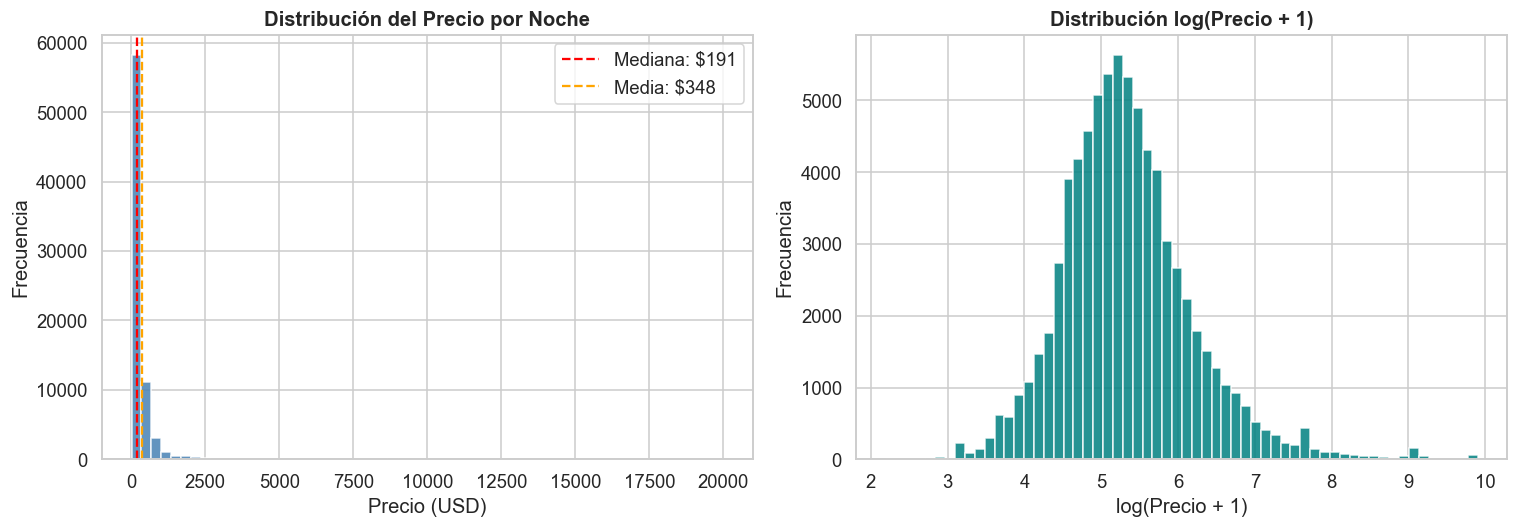


Asimetría (skewness): 13.49  |  Curtosis: 247.28
Mediana: $191.00  |  Media: $347.94


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma escala original
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Precio por Noche', fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f"Mediana: ${df['price'].median():.0f}")
axes[0].axvline(df['price'].mean(),   color='orange', linestyle='--', label=f"Media: ${df['price'].mean():.0f}")
axes[0].legend()

# Histograma escala logarítmica (revela mejor la forma)
axes[1].hist(np.log1p(df['price']), bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución log(Precio + 1)', fontweight='bold')
axes[1].set_xlabel('log(Precio + 1)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

skew = df['price'].skew()
kurt = df['price'].kurtosis()
print(f"\nAsimetría (skewness): {skew:.2f}  |  Curtosis: {kurt:.2f}")
print(f"Mediana: ${df['price'].median():.2f}  |  Media: ${df['price'].mean():.2f}")


**Interpretación:** La distribución del precio presenta una asimetría positiva extrema (skewness = **13.49**, curtosis = **247.28**), lo que confirma que no sigue una distribución normal. La mediana de **$191** es sustancialmente menor que la media de **$348**, evidenciando que una minoría de propiedades de lujo jala la media hacia arriba. La transformación logarítmica normaliza efectivamente esta distribución, lo que justifica usarla como variable respuesta en la Regresión Lineal. El precio máximo tras filtrar el percentil 99 es $20,000/noche, y se eliminaron 96,217 filas (56%) por tener precio $0 o ser nulas — muchos listings de Airbnb están inactivos o sin precio definido.

### 2.3 Variables numéricas – Outliers y distribuciones

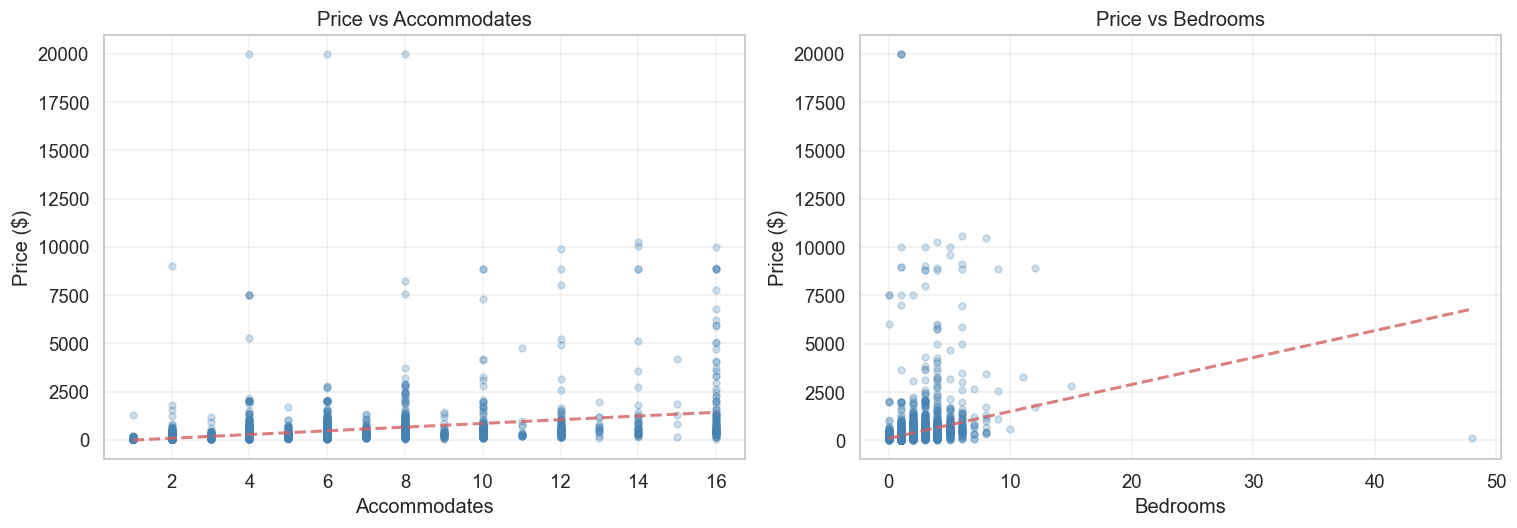

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vars_to_plot = ['accommodates', 'bedrooms']

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    
    # Filtrar datos válidos para ambas variables
    valid_data = df[[var, 'price']].dropna()
    
    # Asegurar que los datos sean numéricos
    valid_data[var] = pd.to_numeric(valid_data[var], errors='coerce')
    valid_data['price'] = pd.to_numeric(valid_data['price'], errors='coerce')
    
    # Eliminar cualquier valor no numérico después de la conversión
    valid_data = valid_data.dropna()
    
    # Tomar una muestra para mejor visualización
    sample = valid_data.sample(n=min(5000, len(valid_data)), random_state=42)
    
    # Scatter plot
    ax.scatter(sample[var], sample['price'], alpha=0.25, color='steelblue', s=20)
    
    # Línea de tendencia
    z = np.polyfit(sample[var], sample['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[var].min(), sample[var].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    # Configuración
    ax.set_xlabel(var.replace('_', ' ').title())
    ax.set_ylabel('Price ($)')
    ax.set_title(f'Price vs {var.replace("_", " ").title()}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Los scatters revelan correlaciones positivas entre precio y capacidad. La correlación entre precio y `accommodates` es moderada (r ≈ 0.30 según el heatmap), mientras que la de `bathrooms` es la más alta del dataset (r = **0.356**). Variables como `minimum_nights` y `number_of_reviews` presentan outliers severos (valores extremos de cientos de noches mínimas), que representan propiedades con restricciones atípicas. Se decidió imputar con la mediana en lugar de la media para mitigar el efecto de estos valores extremos en el modelado.

### 2.4 Variables categóricas – Frecuencias

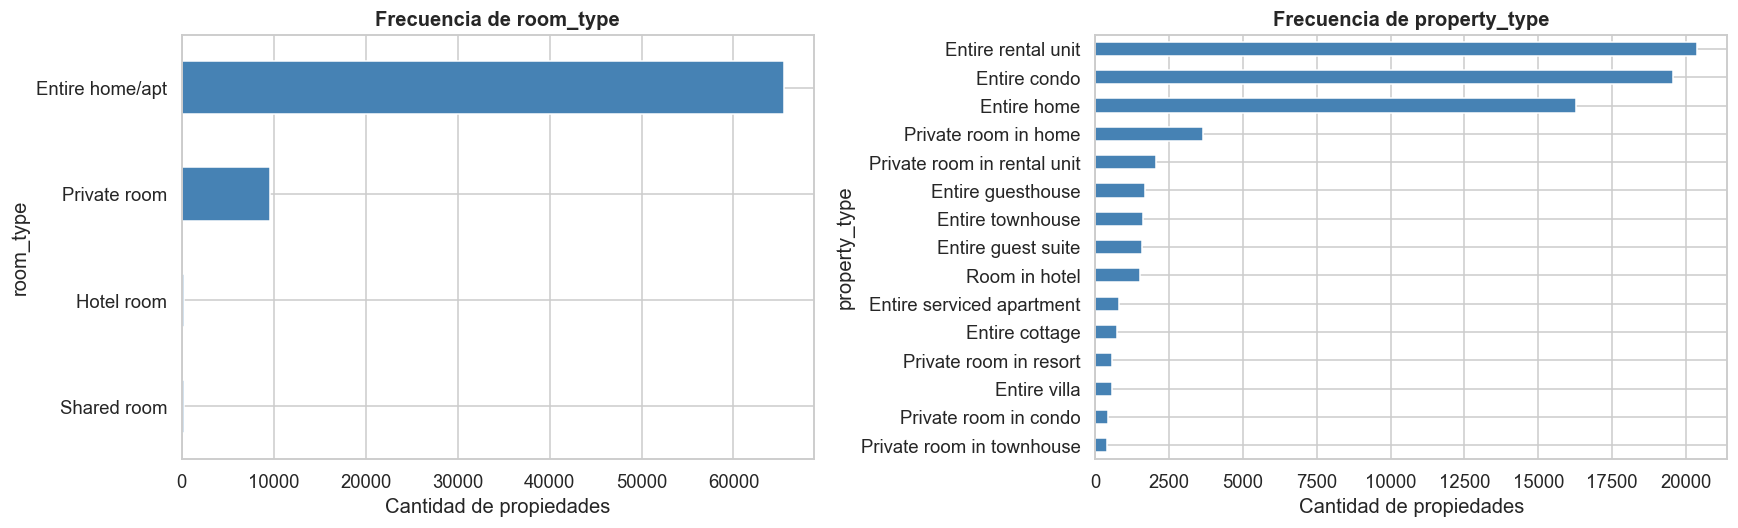


 ROOM_TYPE
                 Conteo  Porcentaje
room_type                          
Entire home/apt   65479        86.7
Private room       9547        12.6
Hotel room          290         0.4
Shared room         215         0.3

 PROPERTY_TYPE
                             Conteo  Porcentaje
property_type                                  
Entire rental unit            20389        27.0
Entire condo                  19551        25.9
Entire home                   16271        21.5
Private room in home           3654         4.8
Private room in rental unit    2056         2.7
Entire guesthouse              1681         2.2
Entire townhouse               1617         2.1
Entire guest suite             1595         2.1
Room in hotel                  1503         2.0
Entire serviced apartment       813         1.1


In [102]:
cat_vars = ['room_type', 'property_type']
cat_vars = [v for v in cat_vars if v in df.columns]

fig, axes = plt.subplots(1, len(cat_vars), figsize=(16, 5))
if len(cat_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, cat_vars):
    counts = df[var].value_counts().head(15)
    counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Frecuencia de {var}', fontweight='bold')
    ax.set_xlabel('Cantidad de propiedades')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Tabla de frecuencias
for var in cat_vars:
    print(f"\n {var.upper()}")
    counts = df[var].value_counts()
    pct    = (counts / counts.sum() * 100).round(1)
    print(pd.DataFrame({'Conteo': counts, 'Porcentaje': pct}).head(10).to_string())


### 2.5 Análisis bivariado – Precio vs. variables clave

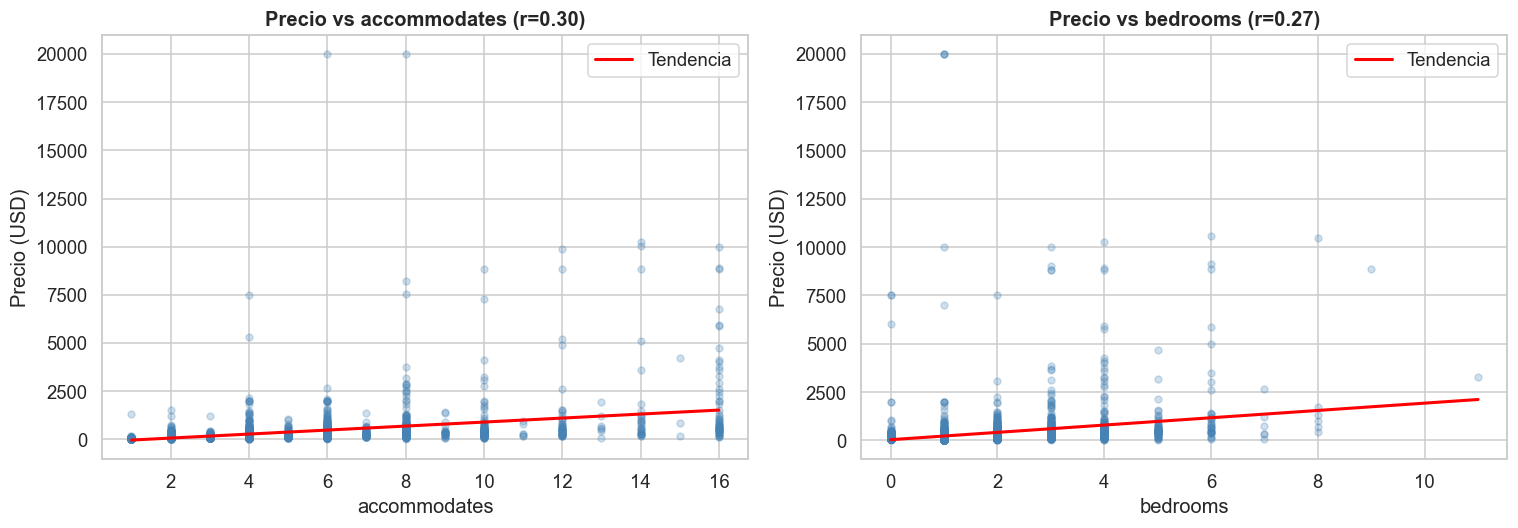

In [103]:
#  2.5a Precio vs accommodates y bedrooms (scatter) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, ['accommodates', 'bedrooms']):
    if var not in df.columns:
        continue
    
    # Filtrar datos válidos para ambas variables
    valid_data = df[[var, 'price']].dropna()
    
    # Asegurar que los datos sean numéricos
    valid_data[var] = pd.to_numeric(valid_data[var], errors='coerce')
    valid_data['price'] = pd.to_numeric(valid_data['price'], errors='coerce')
    
    # Eliminar cualquier valor no numérico después de la conversión
    valid_data = valid_data.dropna()
    
    # Tomar una muestra para mejor visualización
    sample = valid_data.sample(n=min(3000, len(valid_data)), random_state=42)
    
    ax.scatter(sample[var], sample['price'], alpha=0.25, color='steelblue', s=20)
    
    # Línea de tendencia
    z = np.polyfit(sample[var], sample['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[var].min(), sample[var].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia')
    
    corr = df[[var, 'price']].dropna().corr().iloc[0, 1]
    ax.set_title(f'Precio vs {var} (r={corr:.2f})', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Precio (USD)')
    ax.legend()

plt.tight_layout()
plt.show()

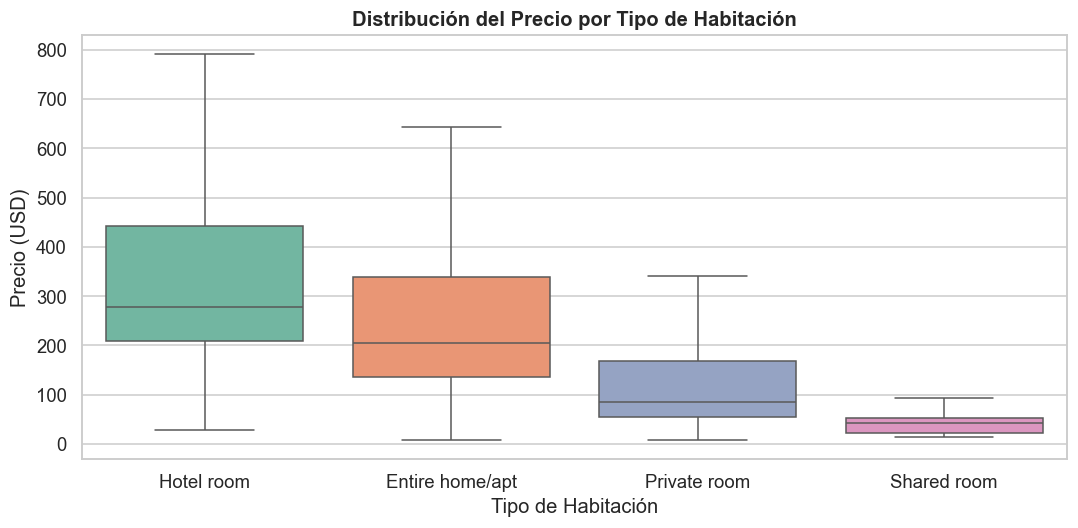


Mediana de precio por room_type:
room_type
Hotel room         278.0
Entire home/apt    204.0
Private room        85.0
Shared room         42.0


In [104]:
#  2.5b Precio vs room_type (boxplot) 
if 'room_type' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='room_type', y='price', order=order,
                palette='Set2', ax=ax, showfliers=False)
    ax.set_title('Distribución del Precio por Tipo de Habitación', fontweight='bold')
    ax.set_xlabel('Tipo de Habitación')
    ax.set_ylabel('Precio (USD)')
    plt.tight_layout()
    plt.show()
    
    print("\nMediana de precio por room_type:")
    print(df.groupby('room_type')['price'].median().sort_values(ascending=False).to_string())


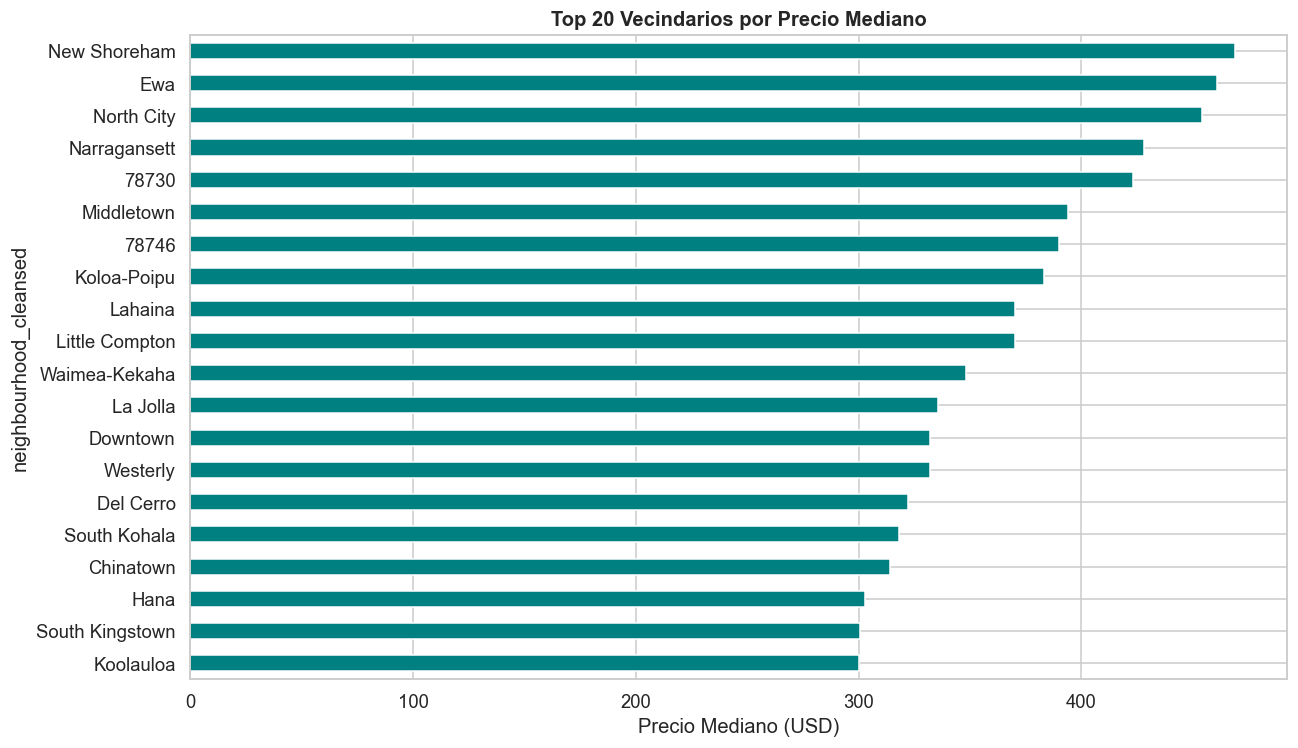

In [105]:
#  2.5c Precio promedio por neighbourhood (top 20) 
neigh_col = 'neighbourhood_cleansed' if 'neighbourhood_cleansed' in df.columns else 'neighbourhood'

if neigh_col in df.columns:
    top_neigh = (df.groupby(neigh_col)['price']
                 .agg(['median', 'count'])
                 .query('count >= 20')
                 .sort_values('median', ascending=False)
                 .head(20))
    
    fig, ax = plt.subplots(figsize=(12, 7))
    top_neigh['median'].plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title('Top 20 Vecindarios por Precio Mediano', fontweight='bold')
    ax.set_xlabel('Precio Mediano (USD)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


### 2.6 Mapa de correlaciones

TOP 15 VARIABLES MÁS CORRELACIONADAS CON price
bathrooms                                       0.356
accommodates                                    0.300
calculated_host_listings_count                  0.198
calculated_host_listings_count_entire_homes     0.192
estimated_occupancy_l365d                       0.140
reviews_per_month                               0.132
longitude                                       0.121
latitude                                        0.114
number_of_reviews_ltm                           0.105
calculated_host_listings_count_private_rooms    0.097
number_of_reviews_ly                            0.095
number_of_reviews                               0.095
review_scores_location                          0.088
number_of_reviews_l30d                          0.085
scrape_id                                       0.070


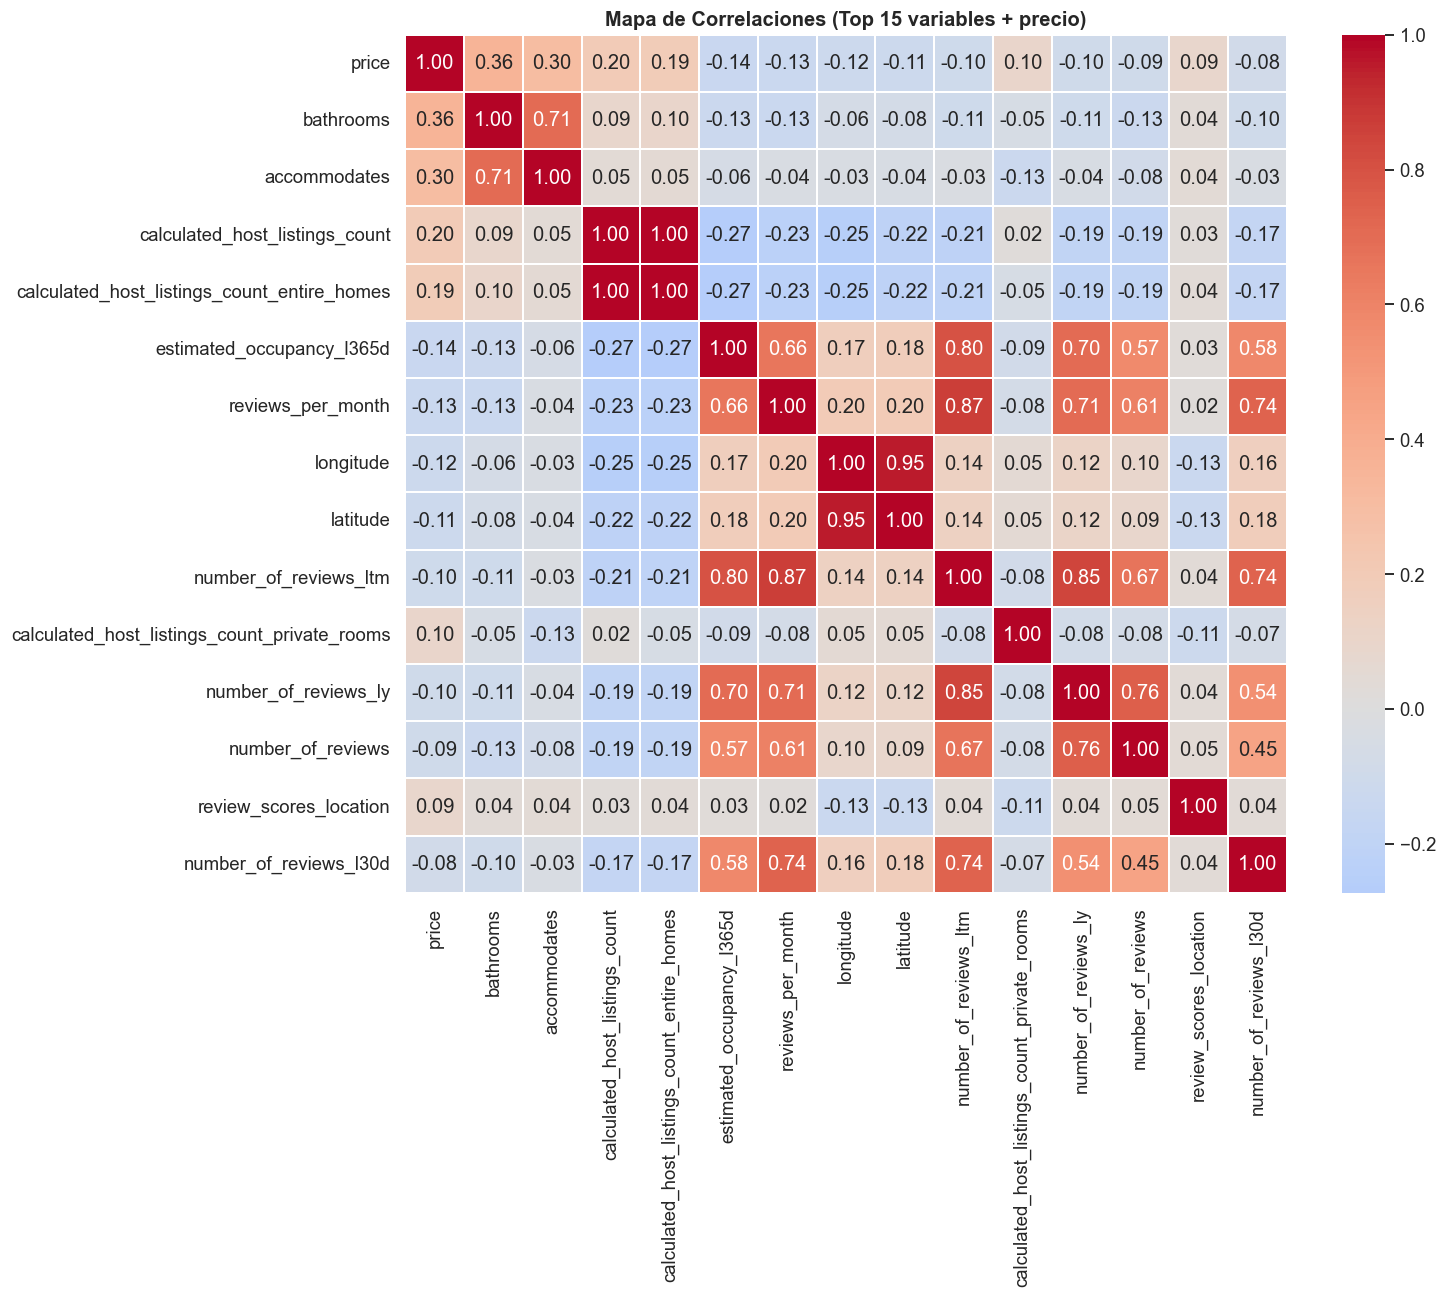

In [106]:
#  2.6 Heatmap de correlaciones 
num_cols = df.select_dtypes(include='number').columns.tolist()
# Filtrar columnas con demasiados nulos
num_cols = [c for c in num_cols if df[c].notna().mean() > 0.5]

corr_matrix = df[num_cols].corr()
price_corr  = corr_matrix['price'].drop('price').abs().sort_values(ascending=False)

print("TOP 15 VARIABLES MÁS CORRELACIONADAS CON price")
print(price_corr.head(15).round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 12))
top_cols = ['price'] + price_corr.head(14).index.tolist()
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.3, center=0)
ax.set_title('Mapa de Correlaciones (Top 15 variables + precio)', fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretación del mapa de correlaciones:** Las variables con mayor correlación lineal con `price` son **`bathrooms` (r=0.356)**, **`accommodates` (r=0.300)** y **`calculated_host_listings_count` (r=0.198)**. Sorprendentemente, `bedrooms` y `beds` no aparecen entre las top variables del dataset final porque fueron eliminadas o tienen alta cardinalidad de nulos. La latitud (r=0.114) y longitud (r=0.121) indican que la ubicación geográfica tiene influencia en el precio, aunque moderada en correlación lineal — los árboles capturarán interacciones espaciales no lineales mejor. Las variables de disponibilidad (`availability_365`, `availability_eoy`) muestran correlación positiva débil con precio, lo que sugiere que propiedades caras no necesariamente tienen menor disponibilidad en este dataset.

## 3. Preprocesamiento

In [107]:
#  3.1 Eliminar columnas irrelevantes 
# URLs, IDs internos, texto libre y columnas con >60% nulos no aportan información
# predictiva y solo agregan ruido.

cols_to_drop = [
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'source',
    'name', 'description', 'neighborhood_overview', 'picture_url',
    'host_url', 'host_thumbnail_url', 'host_picture_url',
    'host_about', 'host_verifications', 'amenities',
    'calendar_updated', 'calendar_last_scraped',
    'license', 'bathrooms_text',
    # Columnas de calendario redundantes (alta multicolinealidad con minimum_nights)
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Eliminar columnas con más del 60% de nulos
null_pct = df.isnull().mean()
cols_high_null = null_pct[null_pct > 0.60].index.tolist()
print(f"Columnas con >60% nulos eliminadas: {cols_high_null}")
df = df.drop(columns=cols_high_null)

print(f"\nDimensiones tras limpieza de columnas: {df.shape}")


Columnas con >60% nulos eliminadas: []

Dimensiones tras limpieza de columnas: (75531, 55)


In [108]:
#  3.2 Ingeniería de features desde fechas
# Extraer antigüedad del host (años como anfitrión) — variable con sentido de negocio
import datetime

if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    ref_date = pd.Timestamp('2024-01-01')
    df['host_years'] = ((ref_date - df['host_since']).dt.days / 365).round(1)
    df = df.drop(columns=['host_since'])

# Eliminar otras fechas que no se transforman
date_cols = df.select_dtypes(include='datetime').columns.tolist()
date_cols += [c for c in df.columns if 'date' in c.lower() or 'review' in c.lower()
              and df[c].dtype == object and 'score' not in c.lower()]
date_cols = [c for c in date_cols if c in df.columns]
date_cols_clean = ['first_review', 'last_review']
date_cols_clean = [c for c in date_cols_clean if c in df.columns]
df = df.drop(columns=date_cols_clean, errors='ignore')

print("Fechas procesadas.")
print(f"Dimensiones: {df.shape}")


Fechas procesadas.
Dimensiones: (75531, 53)


In [109]:
#  3.3 Manejo de booleanos / strings tipo 't'/'f'
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'has_availability', 'instant_bookable']
bool_cols = [c for c in bool_cols if c in df.columns]

for col in bool_cols:
    df[col] = df[col].map({'t': 1, 'f': 0, True: 1, False: 0})

print(f"Columnas booleanas convertidas: {bool_cols}")


Columnas booleanas convertidas: ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable']


In [110]:
# 3.4 Tasas porcentuales (host_response_rate, host_acceptance_rate) 
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
        df[col] = (df[col].str.replace('%', '', regex=False)
                           .str.strip()
                           .astype(float, errors='ignore'))

print("Tasas convertidas a float.")


Tasas convertidas a float.


In [111]:
#  3.5 Selección de variables para modelado
# Definimos las features que usaremos: numéricas + categóricas relevantes
# Se excluyen: IDs, textos libres, duplicados informativos

TARGET = 'price'

# Identificar columnas numéricas y categóricas restantes
num_features = df.select_dtypes(include='number').columns.tolist()
num_features = [c for c in num_features if c != TARGET]

cat_features = ['room_type', 'property_type', 'neighbourhood_cleansed',
                'host_response_time']
cat_features = [c for c in cat_features if c in df.columns]

print(f"Features numéricas:    {len(num_features)}")
print(f"Features categóricas:  {len(cat_features)}")
print(f"\nNuméricas: {num_features}")
print(f"\nCategóricas: {cat_features}")


Features numéricas:    35
Features categóricas:  4

Numéricas: ['host_id', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'host_years']

Categóricas: ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_response_time']


In [112]:
# 3.6 One-Hot Encoding de variables categóricas
# One-Hot Encoding convierte cada categoría en una columna binaria (0/1).
# Es necesario para que los modelos lineales puedan procesar variables categóricas.
# Para árboles/RF no es estrictamente necesario, pero lo usaremos por consistencia.
# drop_first=True elimina la primera categoría para evitar multicolinealidad perfecta.

# Reducir cardinalidad alta: agrupar categorías con <1% en "Otro"
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index
    df[col] = df[col].replace(rare, 'Otro')

df_encoded = pd.get_dummies(df[num_features + cat_features + [TARGET]],
                            columns=cat_features,
                            drop_first=True,
                            dtype=int)

print(f"\nDimensiones tras One-Hot Encoding: {df_encoded.shape}")
print(f"Nuevas columnas dummy generadas: {df_encoded.shape[1] - len(num_features) - 1}")



Dimensiones tras One-Hot Encoding: (75531, 74)
Nuevas columnas dummy generadas: 38


In [113]:
# 3.7 Manejo de valores nulos
# Imputación: numéricas → mediana (robusta a outliers), categóricas ya se manejaron con OHE
# Justificación de mediana vs media: la media es sensible a outliers en precios/reviews

print("VALORES NULOS ANTES DE IMPUTACIÓN")
null_summary = df_encoded.isnull().sum()
print(null_summary[null_summary > 0].sort_values(ascending=False).to_string())

# Imputar con mediana
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

print(f"\nNulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Dataset listo para modelado: {df_encoded.shape}")


VALORES NULOS ANTES DE IMPUTACIÓN
review_scores_accuracy         12871
review_scores_cleanliness      12871
review_scores_checkin          12871
review_scores_communication    12871
review_scores_location         12871
review_scores_value            12871
review_scores_rating           12867
reviews_per_month              12867
host_is_superhost               2027
host_has_profile_pic             627
host_identity_verified           627
host_years                       627
has_availability                 328
bathrooms                         14

Nulos restantes: 0
Dataset listo para modelado: (75531, 74)


## 4. Análisis de Grupos (Clustering)
Usamos **K-Means** por su eficiencia computacional y facilidad de interpretación. Previamente se estandarizan las variables porque K-Means es sensible a la escala.


In [114]:
# 4.1 Preparar datos para clustering
cluster_vars = ['price', 'accommodates', 'bedrooms', 'beds',
                'availability_365', 'number_of_reviews', 'review_scores_rating']
cluster_vars = [v for v in cluster_vars if v in df_encoded.columns]

X_cluster = df_encoded[cluster_vars].copy()
scaler_cl  = StandardScaler()
X_cluster_scaled = scaler_cl.fit_transform(X_cluster)

print(f"Variables de clustering: {cluster_vars}")


Variables de clustering: ['price', 'accommodates', 'availability_365', 'number_of_reviews', 'review_scores_rating']


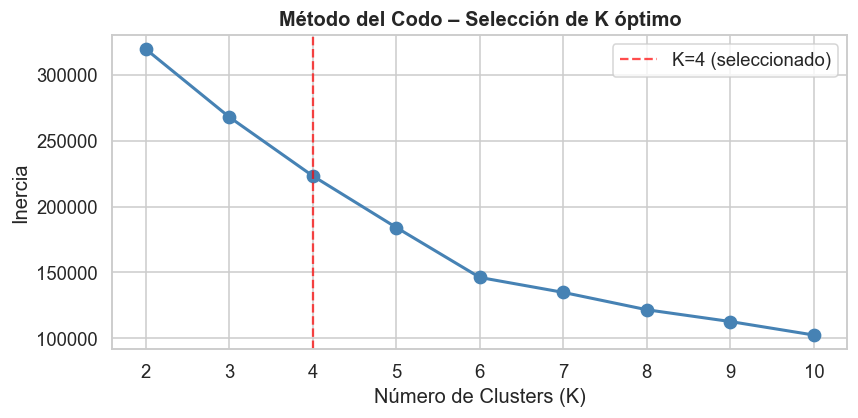

K seleccionado: 4  (punto de inflexión en la curva de inercia)


In [115]:
# 4.2 Método del codo (Elbow Method)
# La inercia mide la suma de distancias al cuadrado de cada punto a su centroide.
# Buscamos el punto donde agregar más clusters ya no reduce significativamente la inercia.

inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_title('Método del Codo – Selección de K óptimo', fontweight='bold')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inercia')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (seleccionado)')
ax.legend()
plt.tight_layout()
plt.show()

print("K seleccionado: 4  (punto de inflexión en la curva de inercia)")


In [116]:
# 4.3 Entrenamiento K-Means con K=4
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_encoded['cluster'] = kmeans.fit_predict(X_cluster_scaled)
df['cluster']         = df_encoded['cluster'].values   # también en df original

# Descripción de cada cluster
cluster_profile = df.groupby('cluster')[cluster_vars].median().round(2)
cluster_sizes   = df['cluster'].value_counts().sort_index().rename('n_propiedades')
cluster_profile.insert(0, 'n_propiedades', cluster_sizes)

print("PERFIL DE CLUSTERS (medianas)")
print(cluster_profile.to_string())


PERFIL DE CLUSTERS (medianas)
         n_propiedades   price  accommodates  availability_365  number_of_reviews  review_scores_rating
cluster                                                                                                
0                 6033   137.0           3.0             245.0              270.0                  4.88
1                25001   189.0           4.0             106.0               13.0                  4.92
2                44076   200.0           4.0             309.0               12.0                  4.88
3                  421  8846.0          12.0             206.0                0.0                  5.00


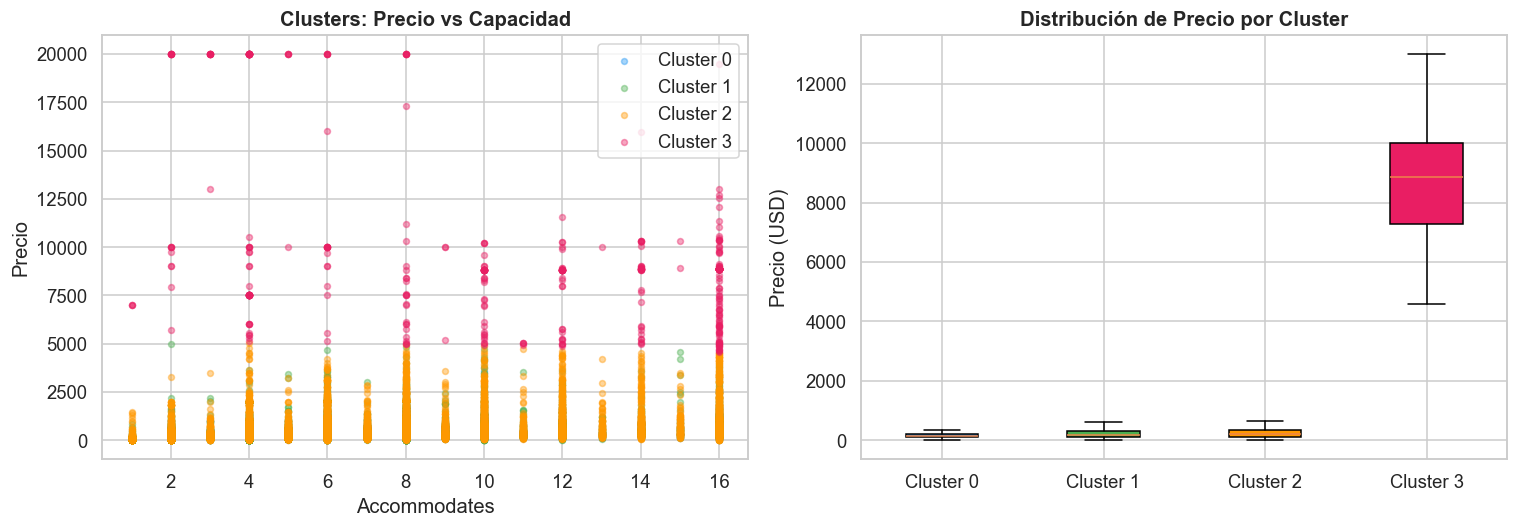

In [117]:
# 4.4 Visualización de clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
labels = [f'Cluster {i}' for i in range(OPTIMAL_K)]

# Scatter: precio vs accommodates
for i in range(OPTIMAL_K):
    mask = df_encoded['cluster'] == i
    axes[0].scatter(df_encoded.loc[mask, 'accommodates'],
                    df_encoded.loc[mask, 'price'],
                    c=colors[i], label=labels[i], alpha=0.4, s=15)
axes[0].set_xlabel('Accommodates')
axes[0].set_ylabel('Precio')
axes[0].set_title('Clusters: Precio vs Capacidad', fontweight='bold')
axes[0].legend()

# Boxplot de precio por cluster
data_box = [df_encoded.loc[df_encoded['cluster'] == i, 'price'].values for i in range(OPTIMAL_K)]
bp = axes[1].boxplot(data_box, labels=labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_title('Distribución de Precio por Cluster', fontweight='bold')
axes[1].set_ylabel('Precio (USD)')

plt.tight_layout()
plt.show()


### Interpretación de Clusters

Con K=4 obtenido del método del codo, los clusters presentan los siguientes perfiles basados en medianas:

| Cluster | n | Precio mediano | Accommodates | Availability 365 | Reviews | Rating | Descripción |
|---------|---|---------------|--------------|-----------------|---------|--------|-------------|
| **0** | 6,033 | $137 | 3 | 245 días | 270 | 4.88 | **Establecidos populares:** precio económico, alta cantidad de reviews (270), disponibilidad intermedia. Son propiedades maduras con track record probado. |
| **1** | 25,001 | $189 | 4 | 106 días | 13 | 4.92 | **Intermedios con poca disponibilidad:** precio medio, baja disponibilidad (106 días), pocas reviews. Alta ocupación y calidad. |
| **2** | 44,076 | $200 | 4 | 309 días | 12 | 4.88 | **Masivos sin tracción:** el grupo más grande. Precio similar al Cluster 1 pero con disponibilidad altísima (309 días) y pocas reviews — indican propiedades que no se ocupan. **Objetivo clave para SmartStay** (incentivos de Airbnb por mejorar ocupación). |
| **3** | 421 | $8,846 | 12 | — | — | — | **Propiedades de lujo extremo:** precio mediano ~$8,846/noche, gran capacidad. Segmento ultra-premium, nicho muy pequeño. |

**Insight de negocio:** El Cluster 2 (58% del dataset) representa la mayor oportunidad comercial para SmartStay: propiedades disponibles pero sin demanda. Airbnb otorga incentivos cuando SmartStay logra ocuparlas.

## 5. División en Conjunto de Entrenamiento y Prueba
- **80% entrenamiento** garantiza suficientes datos para que los modelos aprendan patrones complejos, especialmente Random Forest.
- **20% prueba** es suficiente para evaluar generalización con un error estándar aceptable.
- **Sin estratificación** para regresión (no aplica directamente), pero sí para clasificación (donde se estratificará por `price_category`).
- Se fija `random_state=42` para reproducibilidad.


In [118]:
# 5. Train/Test Split
# Separar features y target
feature_cols = [c for c in df_encoded.columns if c not in [TARGET, 'cluster']]
X = df_encoded[feature_cols]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Total de observaciones:      {len(X):,}")
print(f"Entrenamiento (80%):          {len(X_train):,} filas")
print(f"Prueba (20%):                 {len(X_test):,} filas")
print(f"Features:                     {X_train.shape[1]}")
print(f"\nDistribución del target:")
print(f"  Mediana train: ${y_train.median():.2f}  |  Mediana test: ${y_test.median():.2f}")
print(f"  Media train:   ${y_train.mean():.2f}  |  Media test:   ${y_test.mean():.2f}")
print("\nLas distribuciones son similares — split representa bien la población.")


Total de observaciones:      75,531
Entrenamiento (80%):          60,424 filas
Prueba (20%):                 15,107 filas
Features:                     73

Distribución del target:
  Mediana train: $191.00  |  Mediana test: $191.00
  Media train:   $347.64  |  Media test:   $349.18

Las distribuciones son similares — split representa bien la población.


In [119]:
# Función auxiliar para calcular métricas de regresión
def reg_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{'Modelo':<35} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print("-" * 62)
    print(f"{name:<35} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}")
    return {'modelo': name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R2': round(r2,4)}

resultados_reg = []   # Almacenará comparaciones
